# 01 - Exploratory data analysis

What the dataset looks like before any modelling: how the videos are distributed
across labs, how unbalanced the behaviour classes are, and how much of the raw
tracking is unusable.

1. Metadata (`train.csv`)
2. Tracking and annotation Parquet files
3. Consistency between tracking and annotations
4. Class distribution, globally and per lab
5. Keypoint quality: missing values, speed outliers, body-length violations
6. Trajectories and per-behaviour density maps

Dataset: **MABe Mouse Behavior Detection**, 8,789 videos from 21 labs. The working
subset is `CalMS21_task1`, `CalMS21_task2` and `MABe22_keypoints`.

## 1. Imports and global configuration

In [1]:
import sys
import random
import logging
from pathlib import Path

# Put the project root on the path so src/ can be imported
REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import ast
import json
import warnings
warnings.filterwarnings("ignore")

# ── Reproducibilidad ───────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

import numpy as np
np.random.seed(RANDOM_SEED)

import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats

# ── Logger for non-fatal errors ──────────────────────────────────────────
logging.basicConfig(level=logging.WARNING, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

# Import the project's loader module
from src.data.loader import (
    load_metadata,
    load_tracking,
    load_tracking_wide,
    load_annotations,
    load_lab_annotations,
    load_all_annotations,
    keypoint_quality_report,
    DATASET_DIR,
    TRAIN_TRACKING_DIR,
    TRAIN_ANNOTATION_DIR,
)

# ── Analysis constants ───────────────────────────────────────────────────
SPEED_MAD_K             = 5.0   # robust threshold: median + k*MAD marks an outlier
LENGTH_VAR_THRESHOLD    = 0.20  # a >20% variation in the nose-to-tail_base length

# The working subset of labs
WORKING_LABS = ["CalMS21_task1", "CalMS21_task2", "MABe22_keypoints"]

# Base columns for the tracking reads, so no unnecessary column is loaded
TRK_COLS = ["video_frame", "mouse_id", "bodypart", "x", "y"]

sns.set_theme(style="whitegrid", palette="muted")
print("Entorno configurado correctamente.")
print(f"Dataset dir: {DATASET_DIR}")
print(f"Random seed: {RANDOM_SEED}")


Entorno configurado correctamente.
Dataset dir: C:\Users\User\dev\tfm\dataset\MABe-mouse-behavior-detection
Random seed: 42


## 2. Metadata (`train.csv`)

One row per video, describing the experimental setup: mice (strain, colour, sex,
age), camera (frame rate, resolution), arena (size and shape), tracking method and
the behaviours labelled in that video.

In [2]:
meta = load_metadata("train")

# Pre-index by video_id (string) for O(1) lookups in later cells
meta["video_id"] = meta["video_id"].astype(str)
meta_index = meta.set_index("video_id")

print(f"Shape: {meta.shape}  ({meta.shape[0]} videos, {meta.shape[1]} columns)")
print("\nColumnas:", list(meta.columns))
meta.head(3)


Shape: (8789, 41)  (8789 vídeos, 41 columnas)

Columnas: ['lab_id', 'video_id', 'mouse1_strain', 'mouse1_color', 'mouse1_sex', 'mouse1_id', 'mouse1_age', 'mouse1_condition', 'mouse2_strain', 'mouse2_color', 'mouse2_sex', 'mouse2_id', 'mouse2_age', 'mouse2_condition', 'mouse3_strain', 'mouse3_color', 'mouse3_sex', 'mouse3_id', 'mouse3_age', 'mouse3_condition', 'mouse4_strain', 'mouse4_color', 'mouse4_sex', 'mouse4_id', 'mouse4_age', 'mouse4_condition', 'frames_per_second', 'video_duration_sec', 'pix_per_cm_approx', 'video_width_pix', 'video_height_pix', 'arena_width_cm', 'arena_height_cm', 'arena_shape', 'arena_type', 'body_parts_tracked', 'behaviors_labeled', 'tracking_method', 'n_body_parts', 'n_behaviors_labeled', 'n_mice']


,lab_id,video_id,mouse1_strain,mouse1_color,mouse1_sex,mouse1_id,mouse1_age,mouse1_condition,mouse2_strain,mouse2_color,...,arena_width_cm,arena_height_cm,arena_shape,arena_type,body_parts_tracked,behaviors_labeled,tracking_method,n_body_parts,n_behaviors_labeled,n_mice
0,AdaptableSnail,44566106,CD-1 (ICR),white,male,10.0,8-12 weeks,wireless device,CD-1 (ICR),white,...,60.0,60.0,square,familiar,"[body_center, ear_left, ear_right, headpiece_b...","[mouse1,mouse2,approach, mouse1,mouse2,attack,...",DeepLabCut,18,76,4
1,AdaptableSnail,143861384,CD-1 (ICR),white,male,3.0,8-12 weeks,NaN,CD-1 (ICR),white,...,60.0,60.0,square,familiar,"[body_center, ear_left, ear_right, lateral_lef...","[mouse1,mouse2,approach, mouse1,mouse2,attack,...",DeepLabCut,10,76,4
2,AdaptableSnail,209576908,CD-1 (ICR),white,male,7.0,8-12 weeks,NaN,CD-1 (ICR),white,...,60.0,60.0,square,familiar,"[body_center, ear_left, ear_right, lateral_lef...","[mouse1,mouse2,approach, mouse1,mouse2,attack,...",DeepLabCut,10,76,4


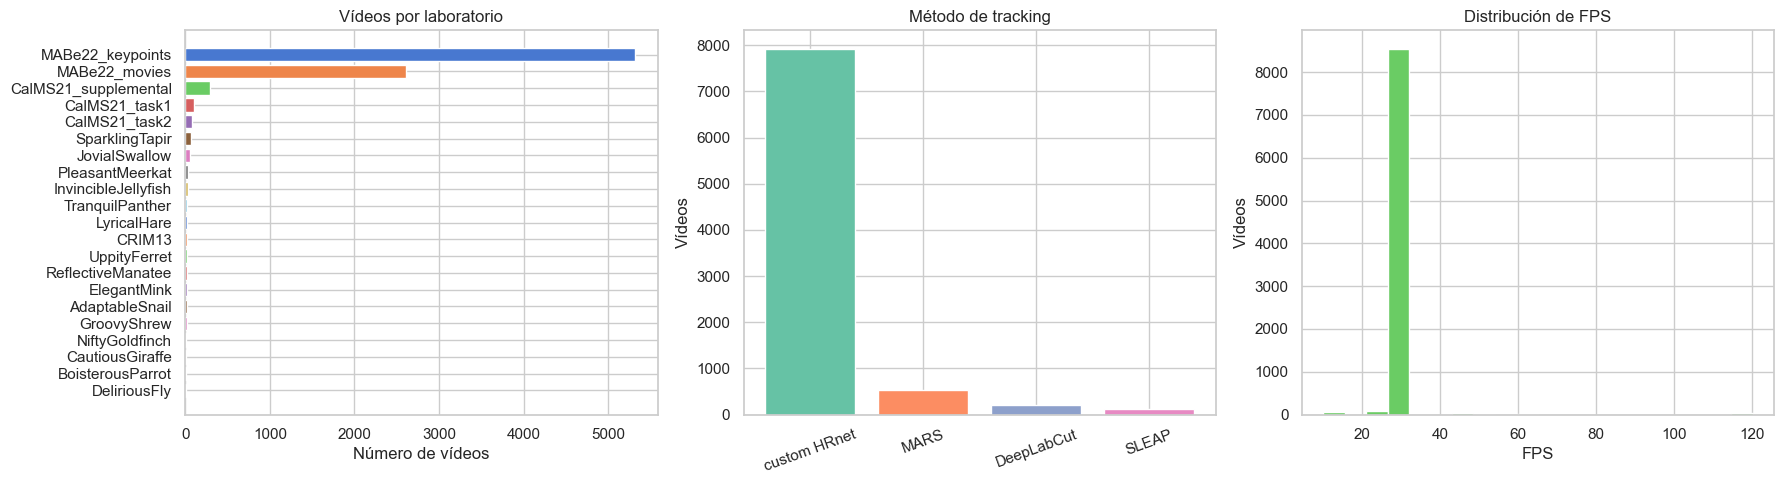


FPS únicos: [np.float64(10.0), np.float64(24.36), np.float64(24.62), np.float64(24.98), np.float64(24.99), np.float64(25.0), np.float64(30.0), np.float64(45.0), np.float64(50.0), np.float64(60.0), np.float64(60.01), np.float64(120.0), np.float64(120.02)]

Formas de arena: {'square': 7961, 'rectangular': 771, 'split rectangluar': 36, 'circular': 21}

Tipos de arena: {'neutral': 8017, 'resident-intruder': 692, 'divided territories': 36, 'familiar': 17, 'CSDS': 17}


In [3]:
# ── 2.1 Distribution by lab and tracking method ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Videos per lab
lab_counts = meta["lab_id"].value_counts()
axes[0].barh(lab_counts.index, lab_counts.values, color=sns.color_palette("muted", len(lab_counts)))
axes[0].set_xlabel("Number of videos")
axes[0].set_title("Videos per lab")
axes[0].invert_yaxis()

# Tracking method
trk_counts = meta["tracking_method"].value_counts()
axes[1].bar(trk_counts.index, trk_counts.values, color=sns.color_palette("Set2", len(trk_counts)))
axes[1].set_title("Tracking method")
axes[1].set_ylabel("Videos")
axes[1].tick_params(axis="x", rotation=20)

# FPS distribution
axes[2].hist(meta["frames_per_second"].dropna(), bins=20, edgecolor="white",
             color=sns.color_palette("muted")[2])
axes[2].set_xlabel("FPS")
axes[2].set_ylabel("Videos")
axes[2].set_title("FPS distribution")

plt.tight_layout()
plt.show()

print("\nDistinct FPS values:", sorted(meta["frames_per_second"].dropna().unique()))
print("\nArena shapes:", meta["arena_shape"].value_counts().to_dict())
print("\nArena types:", meta["arena_type"].value_counts().to_dict())


In [4]:
# ── 2.2 Keypoints available per lab ──────────────────────────────────────
kp_by_lab = (
    meta.groupby("lab_id")["body_parts_tracked"]
    .apply(lambda s: sorted(set(bp for row in s for bp in (row if isinstance(row, list) else []))))
)
print("Keypoints available per lab:")
for lab, kps in kp_by_lab.items():
    print(f"  {lab:25s}  ({len(kps):2d} pts)  {kps}")


Keypoints disponibles por laboratorio:
  AdaptableSnail             (18 pts)  ['body_center', 'ear_left', 'ear_right', 'headpiece_bottombackleft', 'headpiece_bottombackright', 'headpiece_bottomfrontleft', 'headpiece_bottomfrontright', 'headpiece_topbackleft', 'headpiece_topbackright', 'headpiece_topfrontleft', 'headpiece_topfrontright', 'lateral_left', 'lateral_right', 'neck', 'nose', 'tail_base', 'tail_midpoint', 'tail_tip']
  BoisterousParrot           ( 5 pts)  ['body_center', 'ear_left', 'ear_right', 'nose', 'tail_base']
  CRIM13                     ( 7 pts)  ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 'nose', 'tail_base']
  CalMS21_supplemental       ( 7 pts)  ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 'nose', 'tail_base']
  CalMS21_task1              ( 7 pts)  ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 'nose', 'tail_base']
  CalMS21_task2              ( 7 pts)  ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 'nose', 'tail_

In [5]:
# ── 2.3 Statistics of the per-mouse information ──────────────────────────
mouse_cols = {
    "strain":    [f"mouse{i}_strain" for i in range(1, 5)],
    "color":     [f"mouse{i}_color"  for i in range(1, 5)],
    "sex":       [f"mouse{i}_sex"    for i in range(1, 5)],
    "age":       [f"mouse{i}_age"    for i in range(1, 5)],
}

for field, cols in mouse_cols.items():
    vals = pd.concat([meta[c] for c in cols]).dropna()
    print(f"  {field}: {vals.value_counts().to_dict()}")


  strain: {'C57Bl/6J': 14800, 'BTBR': 9786, 'BALB/c': 606, 'CD1': 116, 'C57Bl/6N': 89, 'CD-1 (ICR)': 61, 'CFW': 38, 'C57Bl/6J x Ai148': 24, '129/SvEvTac': 11}
  color: {'black': 14913, 'black and tan': 9786, 'white': 821, 'brown': 11}
  sex: {'male': 25105, 'female': 369}
  age: {'10-20 weeks': 23778, '8-12 weeks': 128, '> 40 weeks': 53, '6-12 weeks': 53, '17-21 weeks': 52, '8-13 weeks': 52, '8-26 weeks': 24, '8-57 weeks': 24, '8 weeks': 21, '4-6 weeks': 21, '7-14 weeks': 16, '12 weeks': 12}


## 3. Tracking data

`train_tracking/{lab}/{video_id}.parquet` holds one row per frame, mouse and
keypoint. The schema is read from the files themselves rather than assumed, because
the keypoint set varies between labs: seven points in CalMS21, twelve in MABe22.

In [6]:
import glob, os

# Example video: the first CalMS21_task1 video
sample_lab = "CalMS21_task1"
sample_files = glob.glob(str(TRAIN_TRACKING_DIR / sample_lab / "*.parquet"))
sample_video_id = Path(sample_files[0]).stem

df_trk = load_tracking(sample_video_id, sample_lab)

print(f"Example video: {sample_lab}/{sample_video_id}")
print(f"Shape: {df_trk.shape}")
print(f"Tipos:\n{df_trk.dtypes}")
print(f"\nFrames totales: {df_trk['video_frame'].nunique()}")
print(f"Distinct mice: {sorted(df_trk['mouse_id'].unique())}")
print(f"Distinct bodyparts: {sorted(df_trk['bodypart'].unique())}")
print(f"\nCoordinate range  x: [{df_trk['x'].min():.1f}, {df_trk['x'].max():.1f}]")
print(f"                      y: [{df_trk['y'].min():.1f}, {df_trk['y'].max():.1f}]")
df_trk.head(8)


Vídeo de ejemplo: CalMS21_task1/1011533560
Shape: (86506, 5)
Tipos:
video_frame      int16
mouse_id          int8
bodypart           str
x              float32
y              float32
dtype: object

Frames totales: 6179
Ratones únicos: [np.int8(1), np.int8(2)]
Bodyparts únicos: ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 'nose', 'tail_base']

Rango de coordenadas  x: [0.0, 1003.6]
                      y: [0.0, 565.0]


,video_frame,mouse_id,bodypart,x,y
0,0,1,ear_left,580.921875,277.673248
1,0,1,ear_right,523.921875,270.673248
2,0,1,hip_left,573.921875,370.673248
3,0,1,hip_right,495.921906,360.673248
4,0,1,neck,545.921875,291.673248
5,0,1,nose,560.921875,237.673264
6,0,1,tail_base,513.921875,428.673248
7,0,2,ear_left,697.249756,187.232559


In [7]:
# ── 3.1 Bodyparts per lab, across every lab ──────────────────────────────
bp_summary = {}
for lab_dir in sorted(TRAIN_TRACKING_DIR.iterdir()):
    if not lab_dir.is_dir():
        continue
    first_file = next(lab_dir.glob("*.parquet"), None)
    if first_file is None:
        continue
    df_tmp = pq.read_table(str(first_file), columns=["bodypart"]).to_pandas()
    bp_summary[lab_dir.name] = sorted(df_tmp["bodypart"].unique())

print(f"{'Lab':30s}  #kp  Keypoints")
print("─" * 120)
for lab, kps in bp_summary.items():
    print(f"{lab:30s}  {len(kps):3d}  {kps}")


Laboratorio                     #kp  Keypoints
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
AdaptableSnail                   10  ['body_center', 'ear_left', 'ear_right', 'lateral_left', 'lateral_right', 'neck', 'nose', 'tail_base', 'tail_midpoint', 'tail_tip']
BoisterousParrot                  5  ['body_center', 'ear_left', 'ear_right', 'nose', 'tail_base']
CalMS21_supplemental              7  ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 'nose', 'tail_base']
CalMS21_task1                     7  ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 'nose', 'tail_base']
CalMS21_task2                     7  ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 'nose', 'tail_base']
CautiousGiraffe                   7  ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 'nose', 'tail_base']
CRIM13                            7  ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 

## 4. Annotations (`train_annotation/`)

One row per behaviour segment: `agent_id`, `target_id`, `action`, `start_frame`,
`stop_frame`. Behaviour is therefore labelled over intervals, not per frame, which
is what the challenge metric scores.

In [8]:
# Load every annotation file
df_ann_all = load_all_annotations()
print(f"Total segmentos anotados: {len(df_ann_all):,}")
print(f"Labs with annotations: {df_ann_all['lab_id'].nunique()}")
print(f"\nSchema:\n{df_ann_all.dtypes}")
df_ann_all.head(6)


Total segmentos anotados: 83,620
Laboratorios con anotaciones: 19

Schema:
agent_id            int8
target_id           int8
action               str
start_frame        int32
stop_frame         int32
video_id             str
lab_id               str
duration_frames    int32
dtype: object


,agent_id,target_id,action,start_frame,stop_frame,video_id,lab_id,duration_frames
0,1,3,chase,2,54,1212811043,AdaptableSnail,52
1,1,3,chase,128,234,1212811043,AdaptableSnail,106
2,3,2,avoid,324,342,1212811043,AdaptableSnail,18
3,3,1,avoid,324,342,1212811043,AdaptableSnail,18
4,1,2,chase,942,1052,1212811043,AdaptableSnail,110
5,4,3,chase,1205,1276,1212811043,AdaptableSnail,71


Estadísticas de duración de segmentos:
       duration_frames  duration_sec
count         83620.00      83620.00
mean             63.71          2.13
std             184.06          5.96
min               0.00          0.00
25%              14.00          0.47
50%              28.00          0.97
75%              59.00          2.03
max           13906.00        463.53


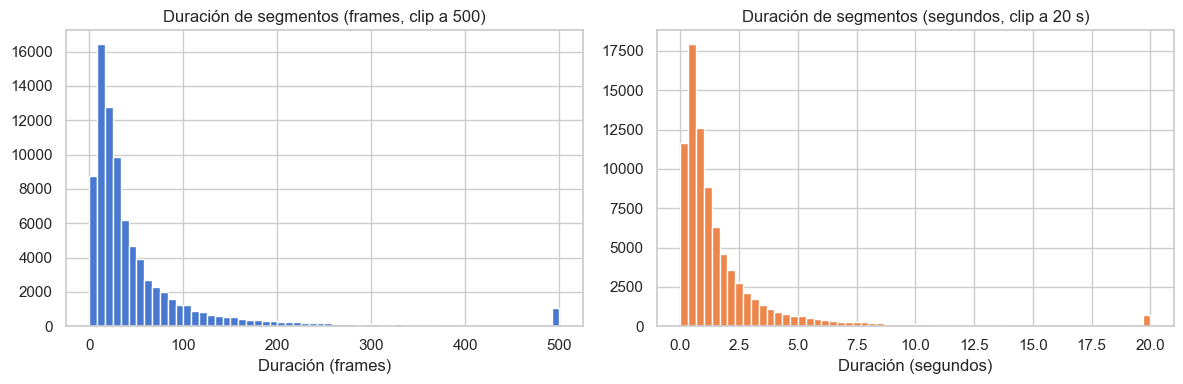


Acciones únicas por laboratorio:
  AdaptableSnail           : ['approach', 'attack', 'avoid', 'chase', 'chaseattack', 'rear', 'submit']
  BoisterousParrot         : ['shepherd']
  CRIM13                   : ['approach', 'attack', 'disengage', 'mount', 'rear', 'selfgroom', 'sniff']
  CalMS21_supplemental     : ['approach', 'attack', 'attemptmount', 'dominancemount', 'intromit', 'mount', 'sniff', 'sniffbody', 'sniffface', 'sniffgenital']
  CalMS21_task1            : ['approach', 'attack', 'genitalgroom', 'intromit', 'mount', 'sniff', 'sniffbody', 'sniffface', 'sniffgenital']
  CalMS21_task2            : ['attack', 'mount', 'sniff']
  CautiousGiraffe          : ['chase', 'escape', 'reciprocalsniff', 'sniff', 'sniffbody', 'sniffgenital']
  DeliriousFly             : ['attack', 'dominance', 'sniff']
  ElegantMink              : ['allogroom', 'attack', 'attemptmount', 'ejaculate', 'intromit', 'mount', 'sniff']
  GroovyShrew              : ['approach', 'attemptmount', 'climb', 'defend', 'dig

In [9]:
# ── 4.1 Segment duration, in frames and in seconds ───────────────────────
# Enrich with FPS via meta_index, which is O(1) per video
df_ann_all["fps"] = (
    df_ann_all["video_id"].astype(str).map(meta_index["frames_per_second"])
)
df_ann_all["duration_sec"] = df_ann_all["duration_frames"] / df_ann_all["fps"]

print("Segment-duration statistics:")
print(df_ann_all[["duration_frames", "duration_sec"]].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_ann_all["duration_frames"].clip(0, 500), bins=60, edgecolor="white",
             color=sns.color_palette("muted")[0])
axes[0].set_xlabel("Duration (frames)")
axes[0].set_title("Segment duration (frames, clipped at 500)")

axes[1].hist(df_ann_all["duration_sec"].clip(0, 20).dropna(), bins=60, edgecolor="white",
             color=sns.color_palette("muted")[1])
axes[1].set_xlabel("Duration (seconds)")
axes[1].set_title("Segment duration (seconds, clipped at 20 s)")
plt.tight_layout()
plt.show()

# Distinct actions per lab
print("\nDistinct actions per lab:")
for lab, grp in df_ann_all.groupby("lab_id"):
    print(f"  {lab:25s}: {sorted(grp['action'].unique())}")


## 5. Tracking and annotations agree

Two checks: every annotated video has a tracking file, and no annotated frame range
runs past the end of its video. Both failures would silently corrupt the windows
built later.

In [10]:
from concurrent.futures import ThreadPoolExecutor

issues = []

def _check_video(args):
    lab, ann_file, trk_dir = args
    vid_id = ann_file.stem
    trk_file = trk_dir / f"{vid_id}.parquet"
    local_issues = []

    # 1. Tracking ausente
    if not trk_file.exists():
        local_issues.append({"lab_id": lab, "video_id": vid_id, "issue": "missing_tracking"})
        return local_issues

    try:
        if vid_id not in meta_index.index:
            return local_issues
        row = meta_index.loc[vid_id]
        fps = row["frames_per_second"]
        dur_sec = row["video_duration_sec"]
        max_frame = int(fps * dur_sec)

        df_a = pq.read_table(
            str(ann_file),
            columns=["start_frame", "stop_frame", "action"]
        ).to_pandas()

        # 2. Frame out of range
        bad_frames = df_a[df_a["stop_frame"] > max_frame]
        if len(bad_frames):
            local_issues.append({
                "lab_id": lab, "video_id": vid_id,
                "issue": f"stop_frame_exceeds_duration ({len(bad_frames)} rows)"
            })

        # 3. Timestamps negativos
        neg_frames = df_a[df_a["start_frame"] < 0]
        if len(neg_frames):
            local_issues.append({
                "lab_id": lab, "video_id": vid_id,
                "issue": f"negative_start_frame ({len(neg_frames)} rows)"
            })

        # 4. start_frame > stop_frame
        inverted = df_a[df_a["start_frame"] > df_a["stop_frame"]]
        if len(inverted):
            local_issues.append({
                "lab_id": lab, "video_id": vid_id,
                "issue": f"start_after_stop ({len(inverted)} rows)"
            })

        # 5. Overlapping annotations from the same agent/action
        df_sorted = df_a.sort_values("start_frame")
        overlap_mask = df_sorted["start_frame"] < df_sorted["stop_frame"].shift(1)
        if overlap_mask.any():
            local_issues.append({
                "lab_id": lab, "video_id": vid_id,
                "issue": f"overlapping_annotations ({overlap_mask.sum()} pairs)"
            })

    except Exception as e:
        local_issues.append({"lab_id": lab, "video_id": vid_id, "issue": f"error: {e}"})

    return local_issues

# Build the task list
tasks = []
for lab_dir in sorted(TRAIN_ANNOTATION_DIR.iterdir()):
    if not lab_dir.is_dir():
        continue
    lab = lab_dir.name
    trk_dir = TRAIN_TRACKING_DIR / lab
    for ann_file in lab_dir.glob("*.parquet"):
        tasks.append((lab, ann_file, trk_dir))

with ThreadPoolExecutor(max_workers=8) as pool:
    results = list(pool.map(_check_video, tasks))

for batch in results:
    issues.extend(batch)

df_issues = pd.DataFrame(issues)
if df_issues.empty:
    print("✓ No inconsistencies detected.")
else:
    print(f"⚠ {len(df_issues)} problemas encontrados:")
    print(df_issues.groupby(["lab_id", "issue"]).size().reset_index(name="count").to_string(index=False))


⚠ 356 problemas encontrados:
              lab_id                                 issue  count
      AdaptableSnail   overlapping_annotations (100 pairs)      1
      AdaptableSnail   overlapping_annotations (106 pairs)      1
      AdaptableSnail    overlapping_annotations (11 pairs)      1
      AdaptableSnail   overlapping_annotations (150 pairs)      1
      AdaptableSnail    overlapping_annotations (26 pairs)      1
      AdaptableSnail    overlapping_annotations (43 pairs)      1
      AdaptableSnail    overlapping_annotations (44 pairs)      1
      AdaptableSnail    overlapping_annotations (46 pairs)      1
      AdaptableSnail    overlapping_annotations (49 pairs)      1
      AdaptableSnail     overlapping_annotations (5 pairs)      1
      AdaptableSnail    overlapping_annotations (51 pairs)      1
      AdaptableSnail    overlapping_annotations (66 pairs)      1
      AdaptableSnail     overlapping_annotations (7 pairs)      1
      AdaptableSnail    overlapping_annotations

## 6. Class distribution

Class imbalance measured globally and per lab. It drives two later decisions: the
loss function for the deep models and the sampling strategy for active learning.

Clase más frecuente:  sniff  (37,837 segmentos)
Clase menos frecuente: ejaculate  (3 segmentos)
Ratio de desequilibrio: 12612.3×

Entropía de la distribución: 3.168 bits  (máx posible: 5.209 bits)
Número efectivo de clases (2^H): 9.0  (de 37 totales)

Frames totales etiquetados por comportamiento:
action
sniff              2,150,590
sniffgenital         703,931
attack               518,870
intromit             347,964
mount                284,931
rear                 230,889
sniffbody            103,274
escape                90,304
defend                89,982
rest                  87,573
approach              85,968
selfgroom             81,761
dig                   78,770
sniffface             71,527
climb                 60,334
reciprocalsniff       40,682
follow                40,144
dominance             38,154
freeze                31,660
shepherd              29,451
chase                 26,704
avoid                 25,674
huddle                24,148
dominancemount        17,55

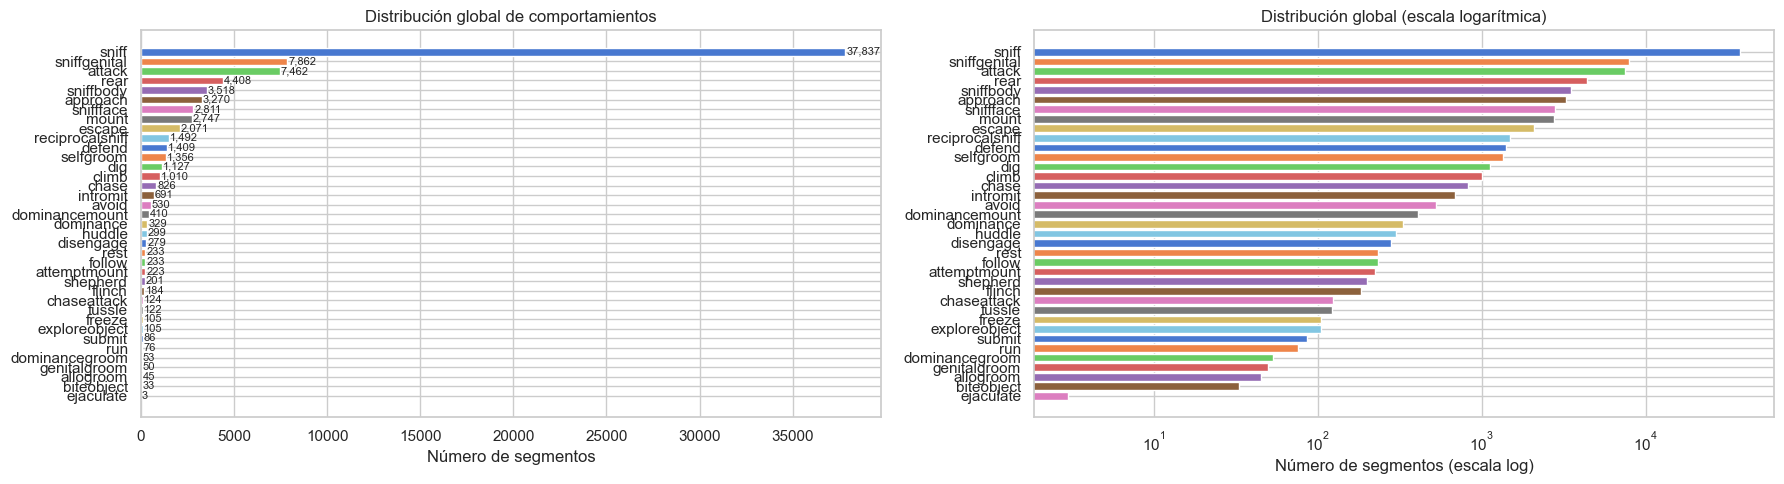

In [11]:
# ── 6.1 Global segment count per behaviour ───────────────────────────────
action_counts = df_ann_all["action"].value_counts()
imbalance_ratio = action_counts.iloc[0] / action_counts.iloc[-1]
print(f"Most frequent class:  {action_counts.index[0]}  ({action_counts.iloc[0]:,} segments)")
print(f"Clase menos frecuente: {action_counts.index[-1]}  ({action_counts.iloc[-1]:,} segmentos)")
print(f"Imbalance ratio: {imbalance_ratio:.1f}x")

# Entropy of the class distribution, in bits
probs = action_counts / action_counts.sum()
entropy_bits = -(probs * np.log2(probs + 1e-12)).sum()
max_entropy  = np.log2(len(action_counts))
print(f"\nDistribution entropy: {entropy_bits:.3f} bits  (max possible: {max_entropy:.3f} bits)")
print(f"Effective number of classes (2^H): {2**entropy_bits:.1f}  (out of {len(action_counts)})")

# Total labelled frames per behaviour
if "duration_frames" in df_ann_all.columns:
    frames_per_action = df_ann_all.groupby("action")["duration_frames"].sum().sort_values(ascending=False)
    print("\nTotal labelled frames per behaviour:")
    print(frames_per_action.apply(lambda x: f"{x:,.0f}").to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Horizontal bars of the global count
colors = sns.color_palette("muted", len(action_counts))
axes[0].barh(action_counts.index[::-1], action_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel("Number of segments")
axes[0].set_title("Global behaviour distribution")
for i, (v, c) in enumerate(zip(action_counts.values[::-1], action_counts.index[::-1])):
    axes[0].text(v + 50, i, f"{v:,}", va="center", fontsize=8)

# Log scale, so the rare classes are visible
axes[1].barh(action_counts.index[::-1], action_counts.values[::-1], color=colors[::-1])
axes[1].set_xscale("log")
axes[1].set_xlabel("Number of segments (log scale)")
axes[1].set_title("Global distribution (log scale)")

plt.tight_layout()
plt.show()


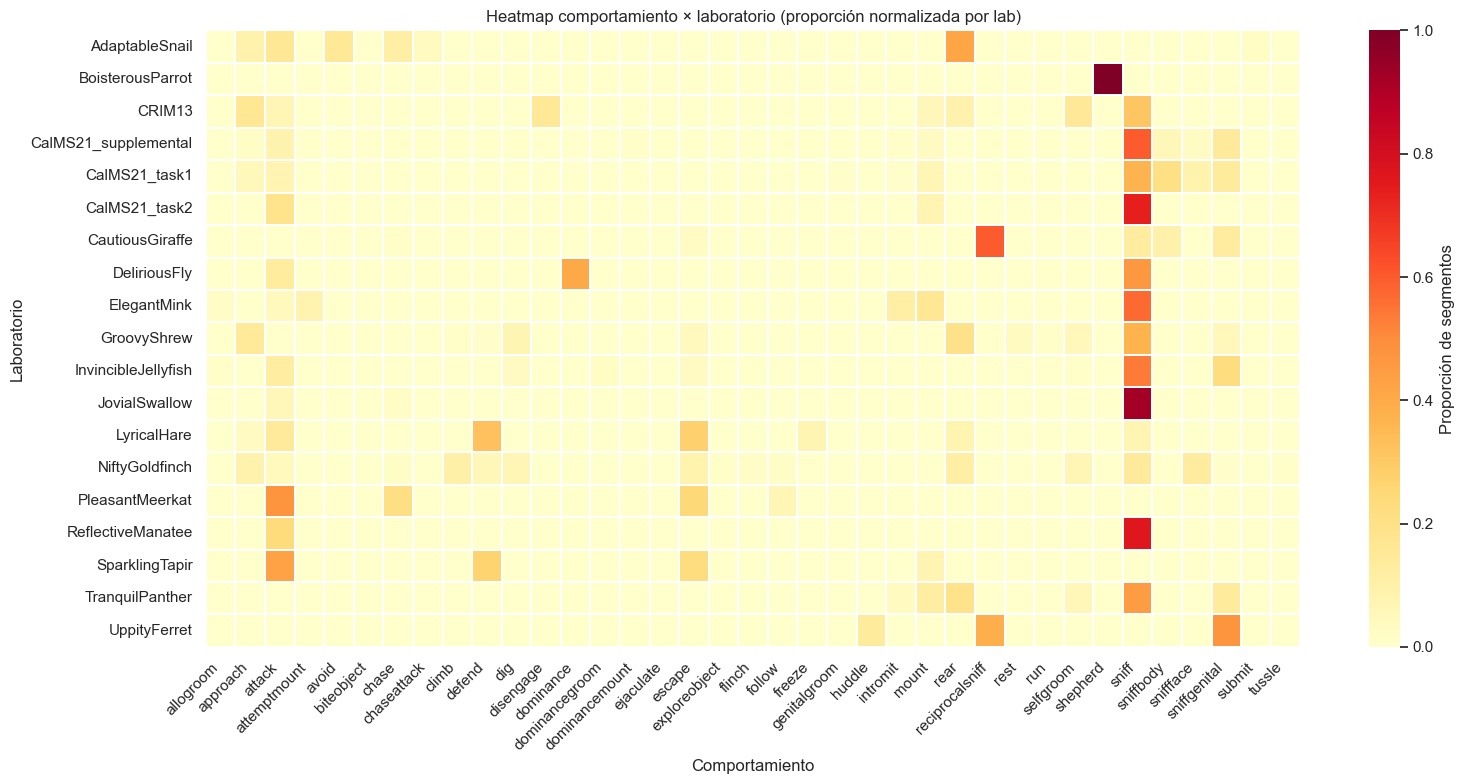

In [12]:
# ── 6.2 Behaviour-by-lab heatmap ─────────────────────────────────────────
pivot = (
    df_ann_all.groupby(["lab_id", "action"])
    .size()
    .unstack(fill_value=0)
)
# Normalise by row, to compare labs holding different numbers of videos
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    pivot_norm,
    ax=ax,
    cmap="YlOrRd",
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"label": "Proportion of segments"},
)
ax.set_title("Behaviour-by-lab heatmap (proportion normalised per lab)")
ax.set_xlabel("Behaviour")
ax.set_ylabel("Lab")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


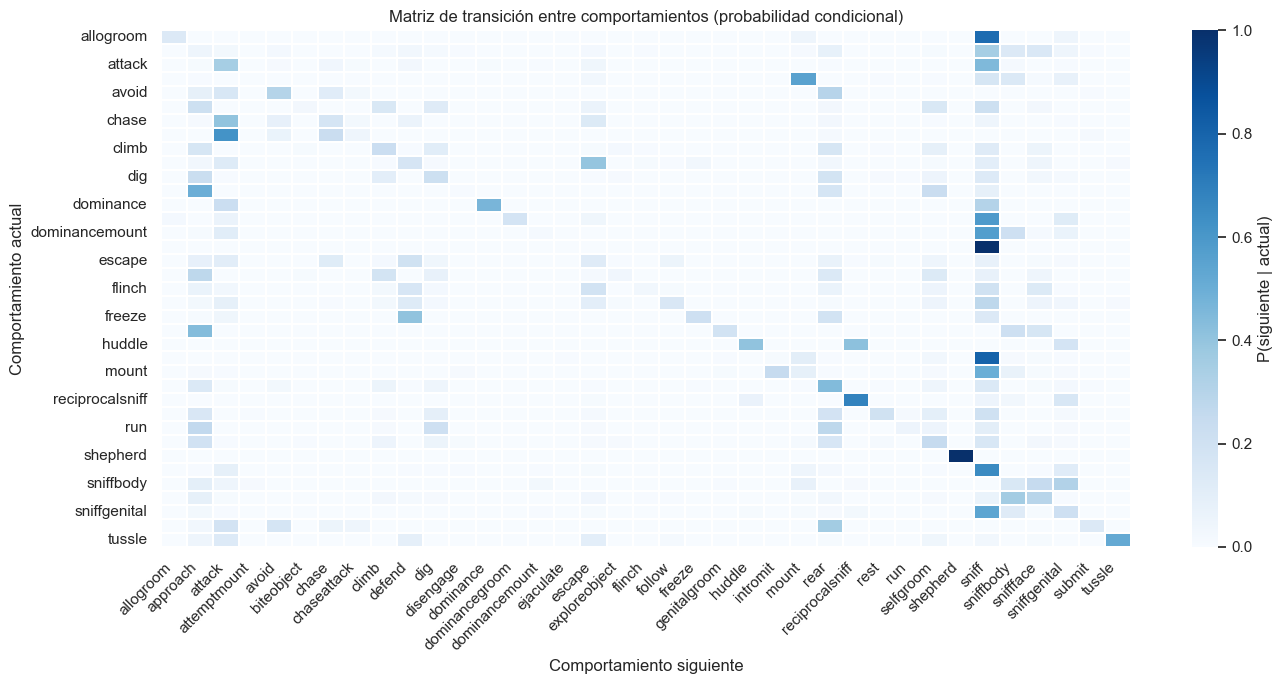


Estadísticas de duración por comportamiento (frames):
                 mediana     p95    total
action                                   
ejaculate          606.0   829.2     1611
intromit           327.0  1548.5   347964
rest               225.0  1195.6    87573
allogroom          114.0   480.4     7580
shepherd           113.0   338.0    29451
freeze             108.0  1032.8    31660
genitalgroom        88.5   374.1     6270
dominancegroom      70.0   215.4     4724
dominance           65.0   317.0    38154
mount               60.0   291.8   284931
dig                 51.0   188.7    78770
submit              44.0   340.5     8478
avoid               44.0    93.0    25674
climb               42.0   158.5    60334
biteobject          41.0   201.2     2326
disengage           39.0    84.0    12021
attack              37.0   231.0   518870
rear                36.0   136.6   230889
huddle              36.0   304.8    24148
dominancemount      32.5   107.0    17556
tussle              3

In [13]:
# ── 6.3 Transition frequencies between behaviours ────────────────────────
# Sorts the segments by video and frame, to find consecutive transitions
df_sorted_ann = df_ann_all.sort_values(["video_id", "start_frame"])
df_sorted_ann["next_action"] = df_sorted_ann.groupby("video_id")["action"].shift(-1)
transitions = (
    df_sorted_ann.dropna(subset=["next_action"])
    .groupby(["action", "next_action"])
    .size()
    .unstack(fill_value=0)
)
# Normalise by row to read them as transition probabilities
trans_norm = transitions.div(transitions.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    trans_norm,
    ax=ax,
    cmap="Blues",
    fmt=".2f",
    annot=len(transitions) <= 12,   # annotate only when there are few classes
    linewidths=0.3,
    cbar_kws={"label": "P(siguiente | actual)"},
)
ax.set_title("Behaviour transition matrix (conditional probability)")
ax.set_xlabel("Next behaviour")
ax.set_ylabel("Current behaviour")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Sequence duration, that is, persistence
if "duration_frames" in df_ann_all.columns:
    print("\nDuration statistics per behaviour (frames):")
    dur_stats = df_ann_all.groupby("action")["duration_frames"].agg(
        mediana="median", p95=lambda x: x.quantile(0.95), total="sum"
    ).sort_values("mediana", ascending=False)
    print(dur_stats.round(1).to_string())


## 7. Keypoint quality: missing values

Missing-value rate per lab and body part. Videos with a high rate are the ones the
skeleton correction has most to work with, so this also sizes the problem that
`MouseSkeleton` is meant to solve.

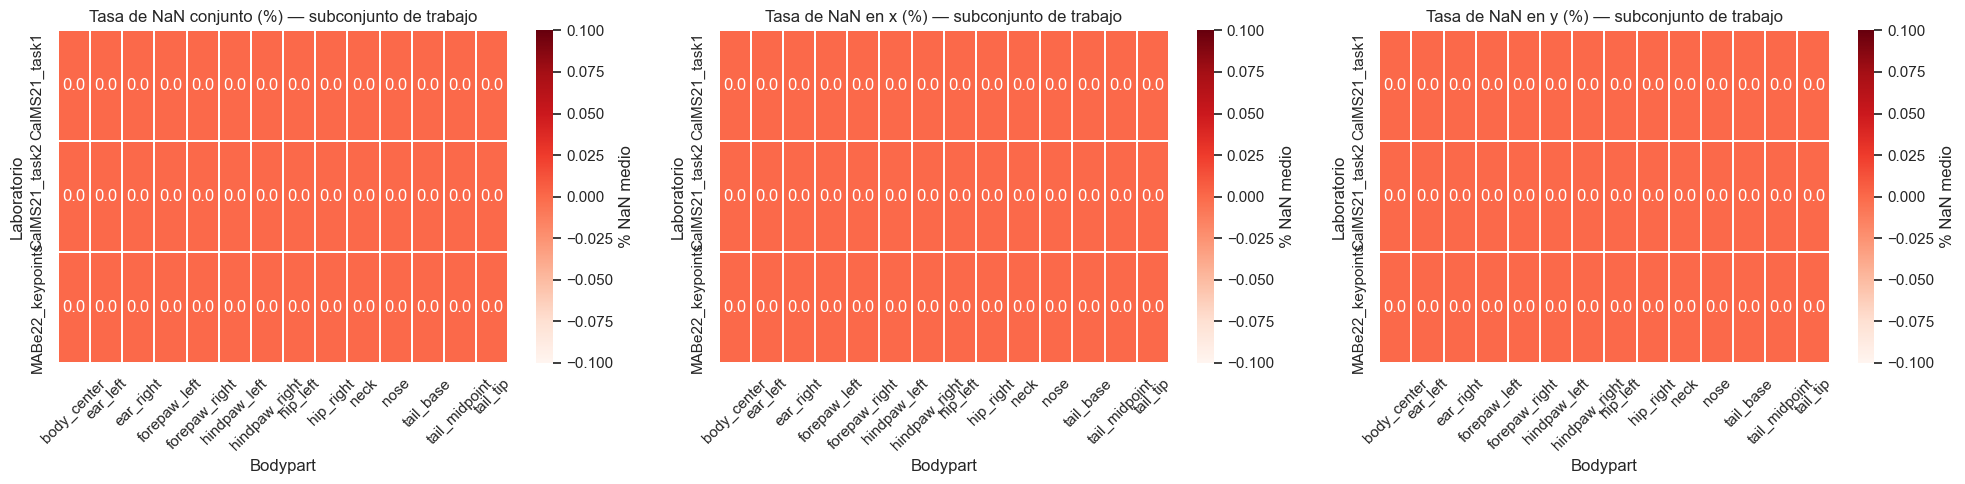


Bodyparts con NaN conjunto >1%:
bodypart
body_center      0.00%
ear_left         0.00%
ear_right        0.00%
forepaw_left     0.00%
forepaw_right    0.00%
hindpaw_left     0.00%
hindpaw_right    0.00%
hip_left         0.00%
hip_right        0.00%
neck             0.00%
Name: joint_nan_rate, dtype: str


In [14]:
nan_records = []
temporal_nan_records = []   # temporal continuity of the NaNs

for lab in WORKING_LABS:
    lab_dir = TRAIN_TRACKING_DIR / lab
    for trk_file in list(lab_dir.glob("*.parquet"))[:30]:  # a 30-video sample per lab
        df_tmp = pq.read_table(str(trk_file), columns=TRK_COLS).to_pandas()
        for bp, grp in df_tmp.groupby("bodypart"):
            x_nan = grp["x"].isna().mean()
            y_nan = grp["y"].isna().mean()
            joint_nan = grp[["x", "y"]].isna().any(axis=1).mean()
            nan_records.append({
                "lab_id": lab, "bodypart": bp,
                "x_nan_rate": x_nan, "y_nan_rate": y_nan, "joint_nan_rate": joint_nan,
            })

            # Continuity analysis: the length of consecutive NaN runs
            is_nan = grp[["x", "y"]].isna().any(axis=1).reset_index(drop=True)
            if is_nan.any():
                # Compute the run lengths of the NaN streaks
                changes = is_nan.ne(is_nan.shift()).cumsum()
                run_lengths = is_nan.groupby(changes).transform("sum")
                nan_runs = run_lengths[is_nan > 0]
                if len(nan_runs):
                    temporal_nan_records.append({
                        "lab_id": lab, "bodypart": bp,
                        "max_consecutive_nan": float(nan_runs.max()),
                        "mean_run_length": float(nan_runs.mean()),
                    })

df_nan = pd.DataFrame(nan_records)
nan_pivot_joint = df_nan.groupby(["lab_id", "bodypart"])["joint_nan_rate"].mean().unstack(fill_value=0)
nan_pivot_x     = df_nan.groupby(["lab_id", "bodypart"])["x_nan_rate"].mean().unstack(fill_value=0)
nan_pivot_y     = df_nan.groupby(["lab_id", "bodypart"])["y_nan_rate"].mean().unstack(fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, pivot, title in zip(
    axes,
    [nan_pivot_joint, nan_pivot_x, nan_pivot_y],
    ["Joint NaN (%)", "NaN in x (%)", "NaN in y (%)"],
):
    sns.heatmap(
        pivot * 100, ax=ax, cmap="Reds", fmt=".1f", annot=True,
        linewidths=0.3, cbar_kws={"label": "% NaN medio"},
    )
    ax.set_title(f"{title} rate - working subset")
    ax.set_xlabel("Bodypart")
    ax.set_ylabel("Lab")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"\nBodyparts with joint NaN above 1%:")
print(df_nan.groupby("bodypart")["joint_nan_rate"].mean().sort_values(ascending=False)
      .head(10).apply(lambda x: f"{x*100:.2f}%"))

# Temporal continuity of the NaNs
if temporal_nan_records:
    df_tnan = pd.DataFrame(temporal_nan_records)
    print("\nLongest run of consecutive NaNs (frames):")
    print(df_tnan.groupby(["lab_id", "bodypart"])["max_consecutive_nan"]
          .mean().unstack(fill_value=0).round(1).to_string())


## 8. Keypoint quality: speed outliers

Frames where a keypoint moves further than a robust threshold, `median + 5 * MAD`,
rescaled by 1.4826 so the cutoff is comparable to a standard deviation. The median
absolute deviation is used instead of the mean and standard deviation because the
speed distribution has heavy tails: the detector jumps we want to flag would
inflate a standard deviation and hide themselves.

Speeds are normalised by frame rate and arena diagonal, so the rate is comparable
across labs recording at different resolutions.

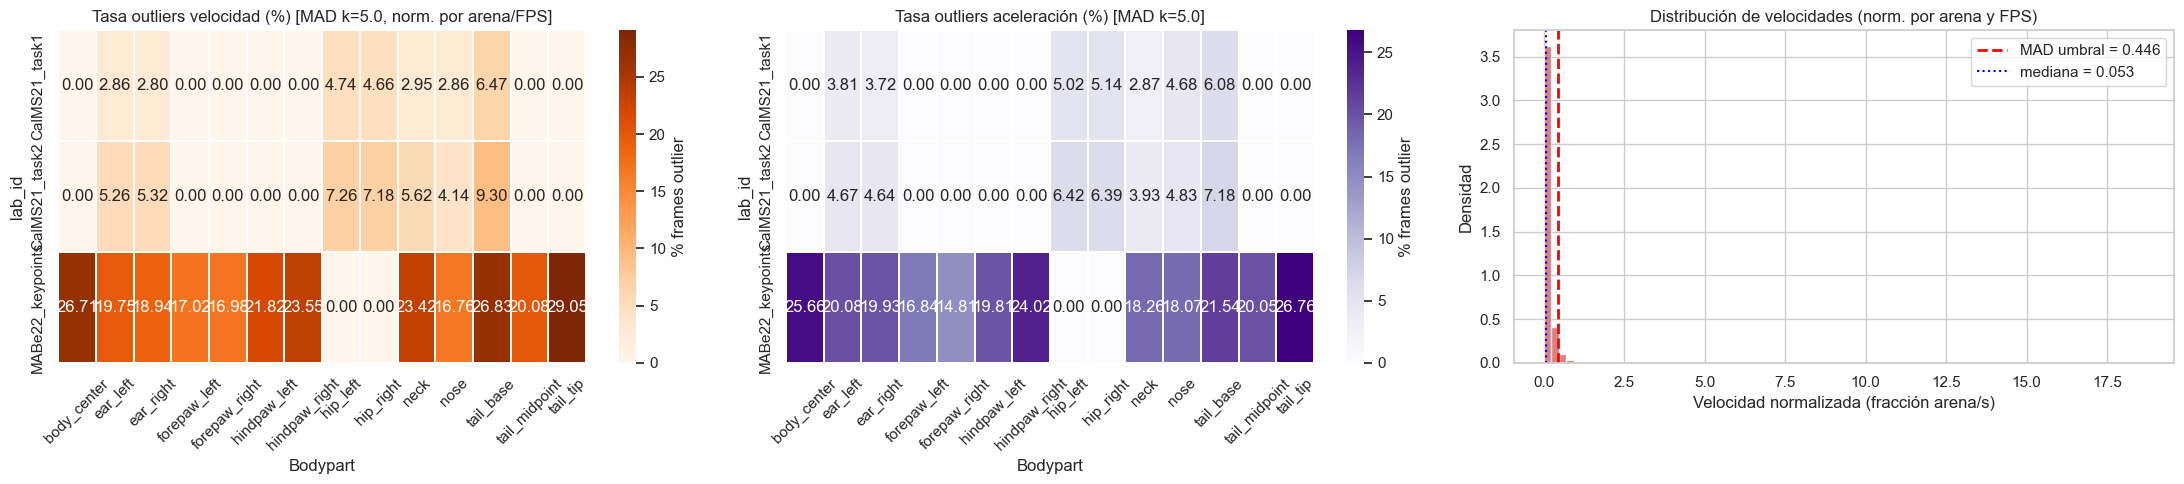

In [15]:
def mad_threshold(arr: np.ndarray, k: float = 5.0) -> float:
    """Robust outlier threshold: median + k * MAD, on a scale comparable to sigma."""
    med = np.nanmedian(arr)
    mad = np.nanmedian(np.abs(arr - med))
    return med + k * mad * 1.4826   # 1.4826 hace MAD comparable a σ bajo normalidad


speed_records = []
accel_records = []    # acceleration, more informative than speed alone
all_speeds_sample = []

for lab in WORKING_LABS:
    lab_dir = TRAIN_TRACKING_DIR / lab
    # Get the sample arena's diagonal, for normalisation
    sample_file = next(lab_dir.glob("*.parquet"), None)
    arena_diag = 1.0
    if sample_file is not None:
        vid_id_str = sample_file.stem
        if vid_id_str in meta_index.index:
            row = meta_index.loc[vid_id_str]
            w = row.get("video_width_pix", 0) or 0
            h = row.get("video_height_pix", 0) or 0
            arena_diag = float(np.sqrt(w**2 + h**2)) if (w and h) else 1.0

    for trk_file in list(lab_dir.glob("*.parquet"))[:20]:
        # Get the FPS, to normalise the speed to px/s
        vid_fps = 30.0
        vid_str = trk_file.stem
        if vid_str in meta_index.index:
            vid_fps = float(meta_index.loc[vid_str].get("frames_per_second", 30) or 30)

        df_tmp = pq.read_table(str(trk_file), columns=TRK_COLS).to_pandas()
        df_tmp = df_tmp.sort_values(["mouse_id", "bodypart", "video_frame"])
        df_tmp["dx"] = df_tmp.groupby(["mouse_id", "bodypart"])["x"].diff()
        df_tmp["dy"] = df_tmp.groupby(["mouse_id", "bodypart"])["y"].diff()
        # Normalised speed: (px/s) / arena_diagonal, a fraction of the arena per second
        df_tmp["speed"] = np.sqrt(df_tmp["dx"]**2 + df_tmp["dy"]**2) * vid_fps / arena_diag
        df_tmp["accel"] = df_tmp.groupby(["mouse_id", "bodypart"])["speed"].diff().abs()

        sample_speeds = df_tmp["speed"].dropna()
        if len(sample_speeds) > 0:
            all_speeds_sample.extend(
                sample_speeds.sample(min(200, len(sample_speeds)), random_state=RANDOM_SEED).tolist()
            )

        for bp, grp in df_tmp.groupby("bodypart"):
            speeds_bp = grp["speed"].dropna().values
            accels_bp = grp["accel"].dropna().values
            if len(speeds_bp) < 5:
                continue
            thr_bp = mad_threshold(speeds_bp, k=SPEED_MAD_K)
            out_bp = (grp["speed"] > thr_bp).mean()
            speed_records.append({"lab_id": lab, "bodypart": bp, "outlier_rate": out_bp})

            if len(accels_bp) >= 5:
                thr_accel = mad_threshold(accels_bp, k=SPEED_MAD_K)
                out_accel = (grp["accel"] > thr_accel).mean()
                accel_records.append({"lab_id": lab, "bodypart": bp, "outlier_rate": out_accel})

df_speed = pd.DataFrame(speed_records)
df_accel = pd.DataFrame(accel_records)
speed_pivot = df_speed.groupby(["lab_id", "bodypart"])["outlier_rate"].mean().unstack(fill_value=0)
accel_pivot = df_accel.groupby(["lab_id", "bodypart"])["outlier_rate"].mean().unstack(fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

sns.heatmap(
    speed_pivot * 100, ax=axes[0], cmap="Oranges", fmt=".2f", annot=True,
    linewidths=0.3, cbar_kws={"label": "% frames outlier"},
)
axes[0].set_title(f"Speed outlier rate (%) [MAD k={SPEED_MAD_K}, normalised by arena/FPS]")
axes[0].set_xlabel("Bodypart")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(
    accel_pivot * 100, ax=axes[1], cmap="Purples", fmt=".2f", annot=True,
    linewidths=0.3, cbar_kws={"label": "% frames outlier"},
)
axes[1].set_title(f"Acceleration outlier rate (%) [MAD k={SPEED_MAD_K}]")
axes[1].set_xlabel("Bodypart")
axes[1].tick_params(axis="x", rotation=45)

# Speed distribution, with the robust MAD threshold
speeds_arr = np.array(all_speeds_sample)
speeds_arr = speeds_arr[~np.isnan(speeds_arr)]
thr_global = mad_threshold(speeds_arr, k=SPEED_MAD_K)
q999 = np.quantile(speeds_arr, 0.999)

axes[2].hist(np.clip(speeds_arr, 0, q999), bins=80, density=True,
             edgecolor="white", color=sns.color_palette("muted")[3], alpha=0.8)
axes[2].axvline(thr_global, color="red", linestyle="--", linewidth=2,
                label=f"MAD threshold = {thr_global:.3f}")
axes[2].axvline(np.nanmedian(speeds_arr), color="blue", linestyle=":", linewidth=1.5,
                label=f"mediana = {np.nanmedian(speeds_arr):.3f}")
axes[2].set_xlabel("Normalised speed (arena fraction/s)")
axes[2].set_ylabel("Densidad")
axes[2].set_title("Speed distribution (normalised by arena and FPS)")
axes[2].legend()

plt.tight_layout()
plt.show()


## 9. Keypoint quality: body-length violations

The nose-to-tail_base segment has a roughly constant length within a video, so a
frame where it departs by more than 20% from the video median is almost certainly a
detection error, usually an occlusion or the two mice being confused with each
other.

This is the baseline that the skeleton correction has to improve on, measured
before any correction is applied.

Tasa de violaciones de longitud corporal por laboratorio:
                 violation_rate                 angle_jump_rate               
                           mean     std     max            mean    std     max
lab_id                                                                        
CalMS21_task1            32.35%  12.36%  70.64%           1.17%  0.77%   4.49%
CalMS21_task2            23.82%   3.83%  32.96%           1.07%  0.50%   2.79%
MABe22_keypoints         24.28%  16.32%  77.30%           1.90%  2.48%  10.02%


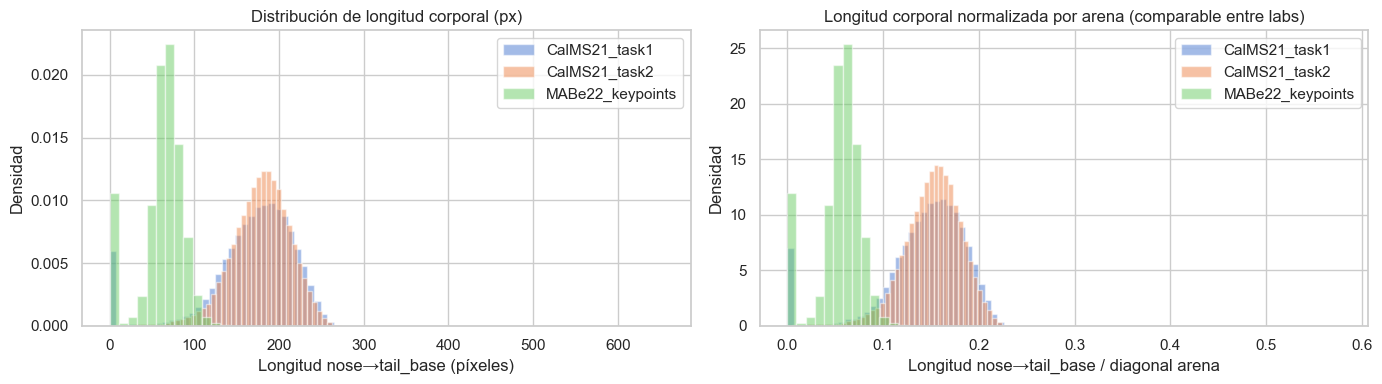


Longitud corporal normalizada por lab:
  CalMS21_task1: mediana=0.1516  std=0.0455  rango=[0.0000, 0.3986]
  CalMS21_task2: mediana=0.1539  std=0.0300  rango=[0.0000, 0.3054]
  MABe22_keypoints: mediana=0.0584  std=0.0238  rango=[0.0000, 0.5777]


In [16]:
len_records = []
body_len_samples = {}   # raw lengths, per lab
body_len_norm_samples = {}  # lengths normalised by the arena diagonal

for lab in WORKING_LABS:
    lab_dir = TRAIN_TRACKING_DIR / lab
    lens_lab = []
    lens_norm_lab = []

    for trk_file in list(lab_dir.glob("*.parquet"))[:30]:
        df_tmp = pq.read_table(str(trk_file), columns=TRK_COLS).to_pandas()
        if "nose" not in df_tmp["bodypart"].values or "tail_base" not in df_tmp["bodypart"].values:
            continue

        # Get the arena diagonal, for normalisation
        vid_str = trk_file.stem
        arena_diag = 1.0
        if vid_str in meta_index.index:
            row = meta_index.loc[vid_str]
            w = row.get("video_width_pix", 0) or 0
            h = row.get("video_height_pix", 0) or 0
            arena_diag = float(np.sqrt(w**2 + h**2)) if (w and h) else 1.0

        nose = df_tmp[df_tmp["bodypart"] == "nose"][["video_frame", "mouse_id", "x", "y"]].rename(
            columns={"x": "nx", "y": "ny"})
        tail = df_tmp[df_tmp["bodypart"] == "tail_base"][["video_frame", "mouse_id", "x", "y"]].rename(
            columns={"x": "tx", "y": "ty"})
        merged = nose.merge(tail, on=["video_frame", "mouse_id"])
        merged["body_len"] = np.sqrt((merged["nx"] - merged["tx"])**2 +
                                     (merged["ny"] - merged["ty"])**2)
        merged["body_len_norm"] = merged["body_len"] / arena_diag

        lens_lab.extend(merged["body_len"].dropna().tolist())
        lens_norm_lab.extend(merged["body_len_norm"].dropna().tolist())

        # Length violations, by a robust within-video z-score
        median_len = merged.groupby("mouse_id")["body_len"].transform("median")
        viol = ((merged["body_len"] - median_len).abs() / median_len > LENGTH_VAR_THRESHOLD)
        len_records.append({
            "lab_id": lab, "file": trk_file.stem,
            "violation_rate": float(viol.mean()),
            "arena_diag_px": arena_diag,
        })

        # Frame-by-frame body angle, to catch angular discontinuities
        merged["angle"] = np.arctan2(merged["ny"] - merged["ty"], merged["nx"] - merged["tx"])
        merged["angle_diff"] = merged.groupby("mouse_id")["angle"].diff().abs()
        # Discontinuidades > π/2 (90°) son sospechosas
        angle_jumps = (merged["angle_diff"] > np.pi / 2).mean()
        len_records[-1]["angle_jump_rate"] = float(angle_jumps)

    body_len_samples[lab] = lens_lab
    body_len_norm_samples[lab] = lens_norm_lab

df_len = pd.DataFrame(len_records)
viol_by_lab = df_len.groupby("lab_id")[["violation_rate", "angle_jump_rate"]].agg(["mean", "std", "max"])

print("Body-length violation rate per lab:")
print(viol_by_lab.map(lambda x: f"{x*100:.2f}%"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Longitudes crudas
for lab, lens in body_len_samples.items():
    if lens:
        axes[0].hist(np.array(lens), bins=60, alpha=0.5, density=True, label=lab)
axes[0].set_xlabel("nose-to-tail_base length (pixels)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Body-length distribution (px)")
axes[0].legend()

# Lengths normalised by the arena diagonal
for lab, lens in body_len_norm_samples.items():
    if lens:
        axes[1].hist(np.array(lens), bins=60, alpha=0.5, density=True, label=lab)
axes[1].set_xlabel("Longitud nose→tail_base / diagonal arena")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Body length normalised by arena (comparable across labs)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistics used to set the skeleton parameters
print("\nNormalised body length per lab:")
for lab, lens in body_len_norm_samples.items():
    if lens:
        arr = np.array(lens)
        print(f"  {lab}: mediana={np.median(arr):.4f}  std={arr.std():.4f}  "
              f"rango=[{arr.min():.4f}, {arr.max():.4f}]")


## 10. 2D trajectories

The nose trajectory for one sample video per lab, with colour encoding time. The
arena outline is drawn on top. What matters here is that arena shape and pixel
scale differ between labs, which is why every geometric quantity used later is
normalised by the arena diagonal.

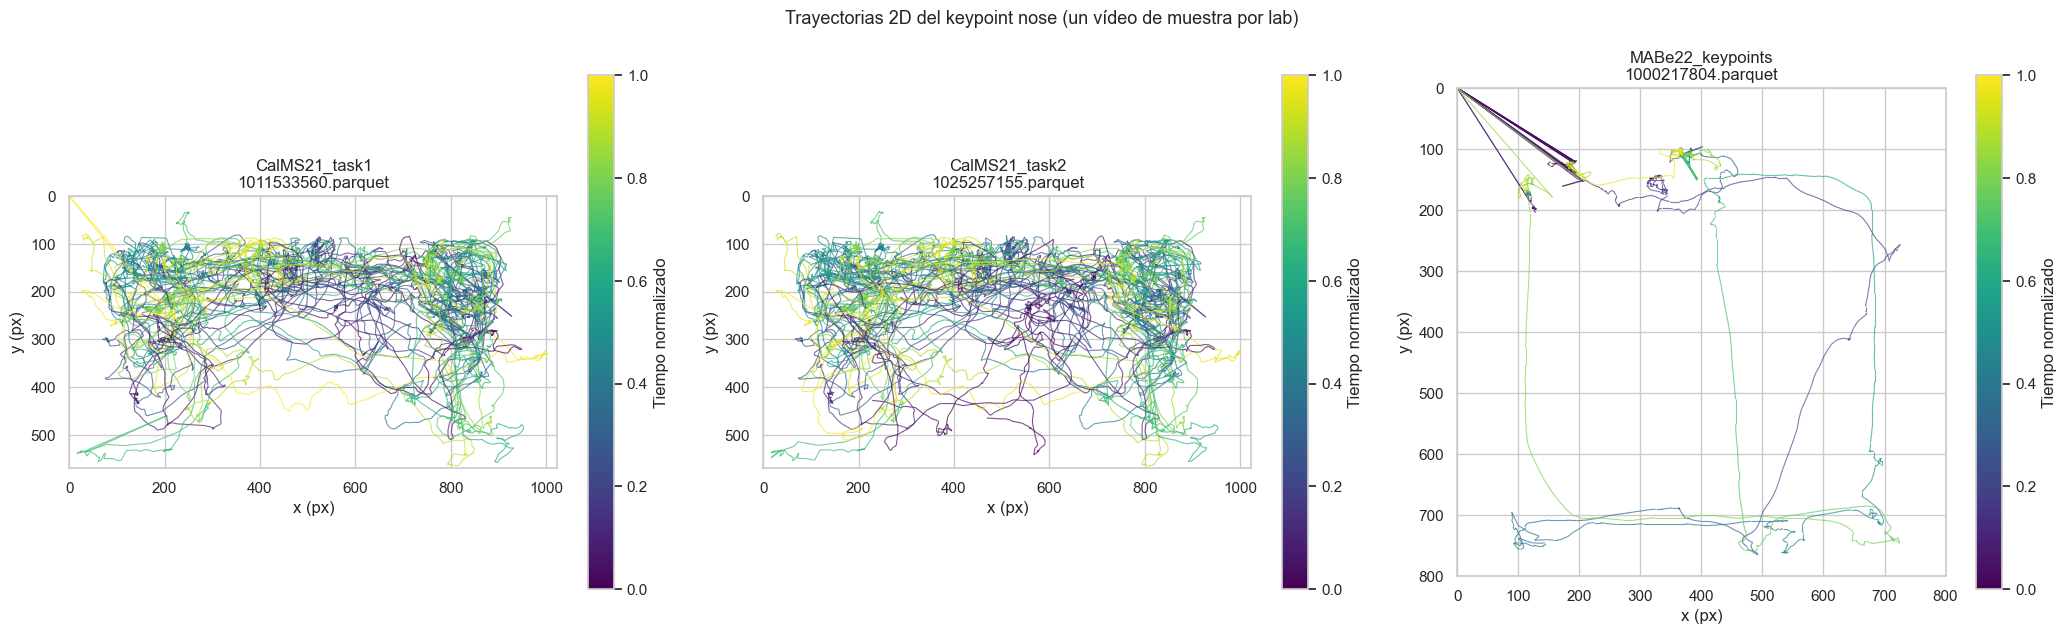

In [17]:
from matplotlib.collections import LineCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig, axes = plt.subplots(1, len(WORKING_LABS), figsize=(7 * len(WORKING_LABS), 6))
if len(WORKING_LABS) == 1:
    axes = [axes]

for ax, lab in zip(axes, WORKING_LABS):
    lab_dir = TRAIN_TRACKING_DIR / lab
    sample_file = next(lab_dir.glob("*.parquet"), None)
    if sample_file is None:
        ax.set_title(f"{lab}\n(no data)")
        continue

    df_tmp = pq.read_table(str(sample_file), columns=TRK_COLS).to_pandas()
    nose_df = df_tmp[df_tmp["bodypart"] == "nose"].sort_values("video_frame")

    # Get the arena dimensions via meta_index, which is O(1)
    vid_id_str = sample_file.stem
    w_pix, h_pix = None, None
    if vid_id_str in meta_index.index:
        row = meta_index.loc[vid_id_str]
        w_raw = row.get("video_width_pix")
        h_raw = row.get("video_height_pix")
        w_pix = int(w_raw) if pd.notna(w_raw) and w_raw else None
        h_pix = int(h_raw) if pd.notna(h_raw) and h_raw else None

    cmap = plt.cm.viridis
    mice = nose_df["mouse_id"].unique()

    for mouse in sorted(mice):
        m_df = nose_df[nose_df["mouse_id"] == mouse].dropna(subset=["x", "y"])
        if len(m_df) < 2:
            continue

        xy = m_df[["x", "y"]].values
        t = np.linspace(0, 1, len(xy))

        segs = np.stack([xy[:-1], xy[1:]], axis=1)
        lc = LineCollection(segs, cmap=cmap, norm=Normalize(0, 1), alpha=0.7, linewidth=0.8)
        lc.set_array(t[:-1])
        ax.add_collection(lc)

    if w_pix and h_pix:
        ax.set_xlim(0, w_pix)
        ax.set_ylim(h_pix, 0)
    else:
        ax.autoscale()

    ax.set_aspect("equal")
    ax.set_title(f"{lab}\n{sample_file.name}")
    ax.set_xlabel("x (px)")
    ax.set_ylabel("y (px)")
    fig.colorbar(ScalarMappable(norm=Normalize(0, 1), cmap=cmap), ax=ax, label="Tiempo normalizado")

plt.suptitle("2D trajectories of the nose keypoint (one sample video per lab)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


## 11. Per-behaviour density maps

Where each behaviour happens in the arena, for the two labs that have annotations
(`CalMS21_task1` and `CalMS21_task2`). Each cell counts nose frames during segments
of that behaviour.

The question this answers is whether absolute position discriminates behaviour on
its own. It does not, which is why the feature vector is built from relative
quantities instead: speeds, angles and inter-mouse distances.

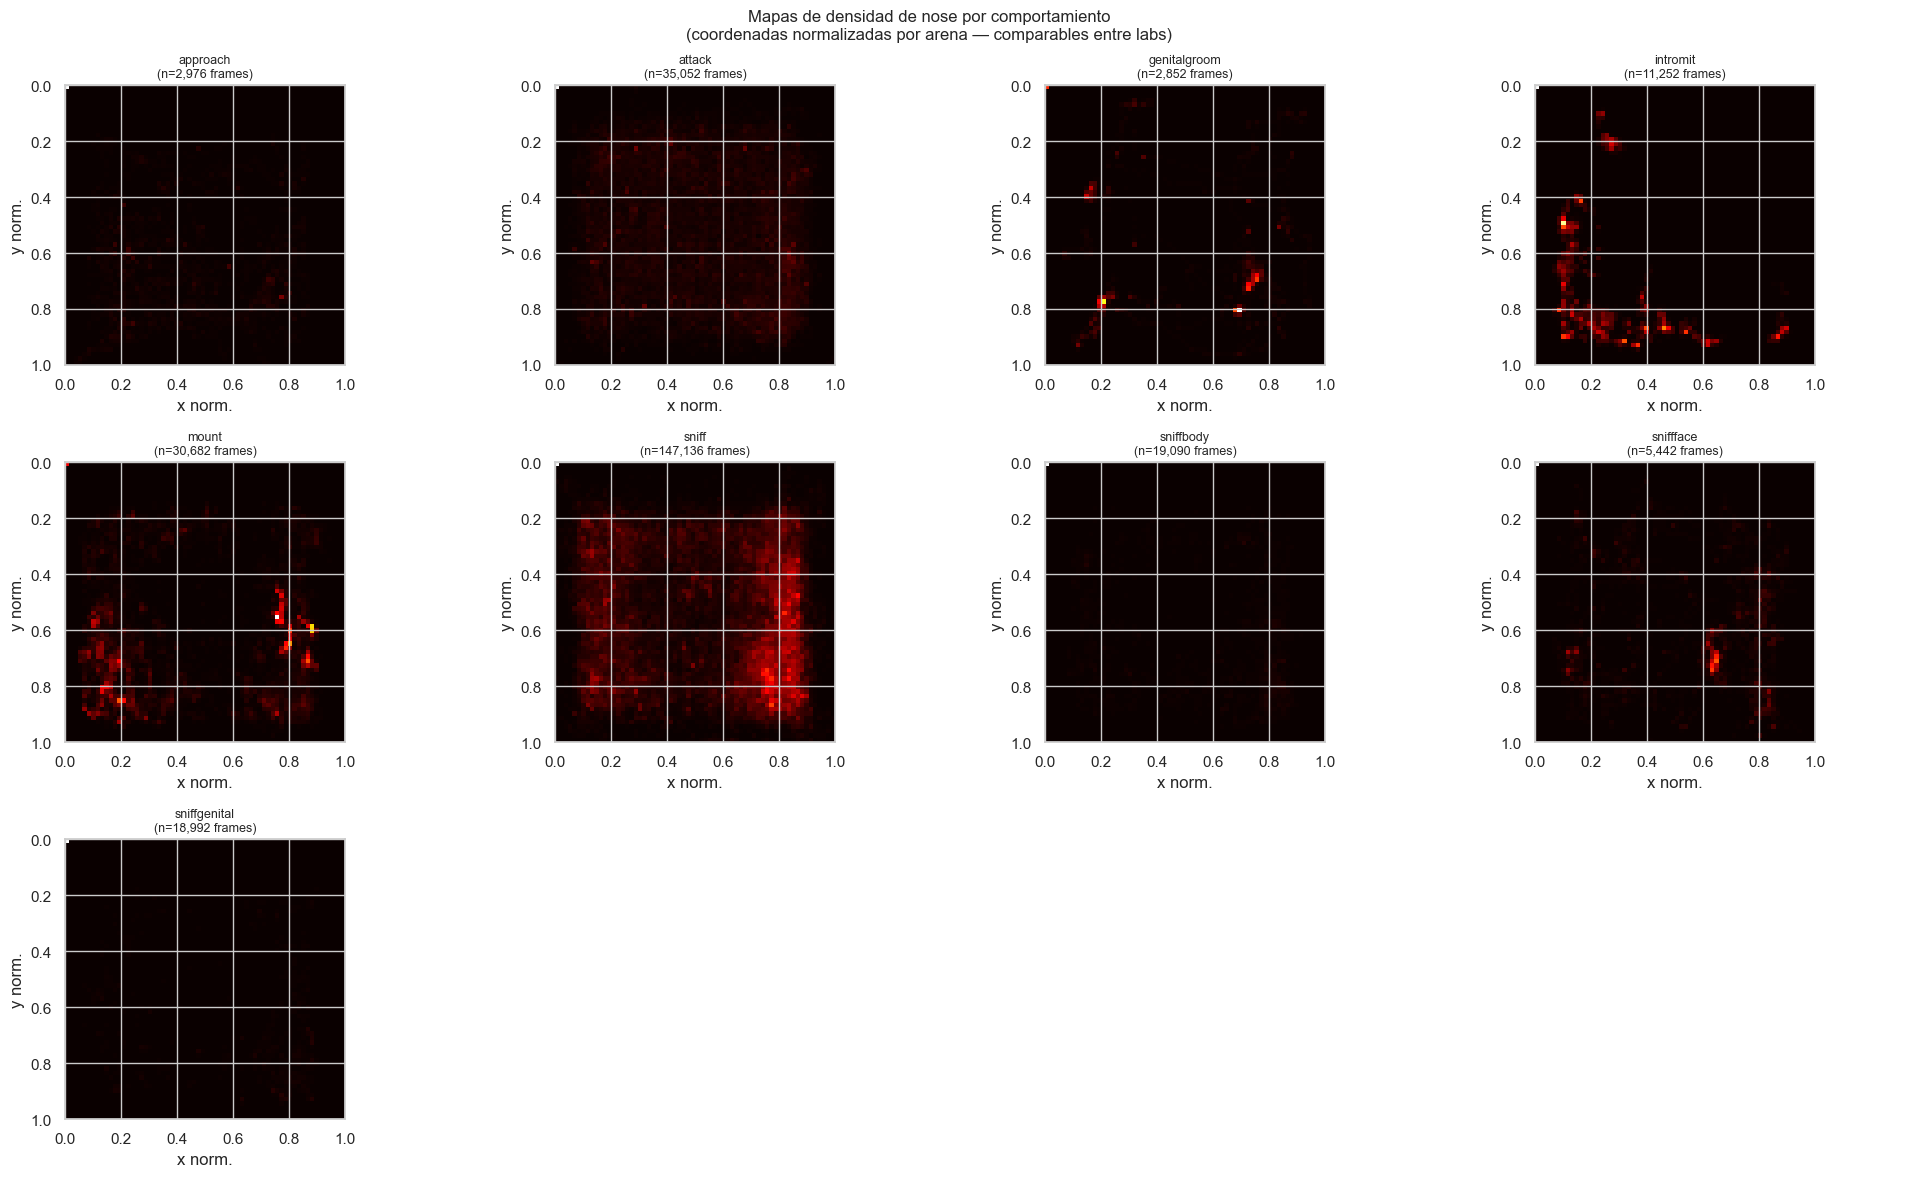

In [18]:
# Only for labs whose annotations include nose
ANNOTATED_WORKING = [l for l in WORKING_LABS if l != "MABe22_keypoints"]

# Collect behaviour -> list of (x_norm, y_norm).
# The coordinates are normalised by arena size so labs are comparable.
behavior_positions: dict[str, list] = {}
N_GRID = 64

for lab in ANNOTATED_WORKING:
    ann_dir = TRAIN_ANNOTATION_DIR / lab
    trk_dir = TRAIN_TRACKING_DIR / lab
    for ann_file in list(ann_dir.glob("*.parquet"))[:15]:
        vid_id = ann_file.stem
        trk_file = trk_dir / f"{vid_id}.parquet"
        if not trk_file.exists():
            continue

        # Get the arena dimensions, for normalisation
        w_pix, h_pix = 1.0, 1.0
        if vid_id in meta_index.index:
            row = meta_index.loc[vid_id]
            w_raw = row.get("video_width_pix")
            h_raw = row.get("video_height_pix")
            w_pix = float(w_raw) if pd.notna(w_raw) and w_raw else 1.0
            h_pix = float(h_raw) if pd.notna(h_raw) and h_raw else 1.0

        try:
            df_a = pq.read_table(
                str(ann_file), columns=["start_frame", "stop_frame", "action"]
            ).to_pandas()
            df_t = pq.read_table(str(trk_file), columns=TRK_COLS).to_pandas()
            nose = df_t[df_t["bodypart"] == "nose"][["video_frame", "x", "y"]].dropna()

            # Scale the coordinates to [0, 1]
            nose = nose.copy()
            nose["x"] = nose["x"] / w_pix
            nose["y"] = nose["y"] / h_pix

            for _, row in df_a.iterrows():
                action = row["action"]
                frames = nose[
                    (nose["video_frame"] >= row["start_frame"]) &
                    (nose["video_frame"] <= row["stop_frame"])
                ]
                if frames.empty:
                    continue
                behavior_positions.setdefault(action, []).extend(
                    list(zip(frames["x"], frames["y"]))
                )
        except Exception as e:
            logger.warning("density map %s/%s: %s", lab, vid_id, e)
            continue

actions_list = sorted(behavior_positions.keys())
n = len(actions_list)
if n == 0:
    print("Not enough data for the density maps.")
else:
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, action in enumerate(actions_list):
        xy = np.array(behavior_positions[action])
        # Clip to [0, 1] in case a coordinate falls outside the arena
        xy = np.clip(xy, 0, 1)
        H, xedges, yedges = np.histogram2d(xy[:, 0], xy[:, 1], bins=N_GRID,
                                            range=[[0, 1], [0, 1]])
        axes[i].imshow(H.T, origin="upper", aspect="equal", cmap="hot",
                       interpolation="nearest", extent=[0, 1, 1, 0])
        axes[i].set_title(f"{action}\n(n={len(xy):,} frames)", fontsize=9)
        axes[i].set_xlabel("x norm.")
        axes[i].set_ylabel("y norm.")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        "Nose density maps per behaviour\n"
        "(coordinates normalised by arena, so labs are comparable)",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


## 12. Consolidated quality report

All the quality metrics above, aggregated per video over a sample of 50 files per
lab, and written to `outputs/eda_quality_report.csv` and `.parquet` for the later
notebooks to read.

In [19]:
import os

# Use keypoint_quality_report over a representative sample
quality_rows = []
errors_skipped = 0

for lab in WORKING_LABS:
    lab_dir = TRAIN_TRACKING_DIR / lab
    files = list(lab_dir.glob("*.parquet"))[:50]
    for trk_file in files:
        vid_id = trk_file.stem
        try:
            report = keypoint_quality_report(vid_id, lab)
            quality_rows.append({
                "lab_id": lab,
                "video_id": vid_id,
                **report,
            })
        except FileNotFoundError as e:
            logger.warning("quality_report - file not found: %s (%s)", vid_id, e)
            errors_skipped += 1
        except KeyError as e:
            logger.warning("quality_report - column missing in %s: %s", vid_id, e)
            errors_skipped += 1
        except Exception as e:
            logger.warning("quality_report — error inesperado en %s: %s", vid_id, e)
            errors_skipped += 1

if errors_skipped:
    print(f"⚠ {errors_skipped} videos skipped because of errors; see the warnings above.")

df_quality = pd.DataFrame(quality_rows)

# Add the length-violation rate from df_len
if not df_len.empty:
    len_merge = df_len.rename(columns={"file": "video_id"})[["lab_id", "video_id", "violation_rate"]]
    df_quality = df_quality.merge(len_merge, on=["lab_id", "video_id"], how="left")

# Add the speed-outlier rate, averaged per lab
speed_lab = (
    df_speed.groupby("lab_id")["outlier_rate"].mean()
    .reset_index()
    .rename(columns={"outlier_rate": "speed_outlier_rate_lab_avg"})
)
df_quality = df_quality.merge(speed_lab, on="lab_id", how="left")

print(f"Quality report: {len(df_quality)} videos, {df_quality.columns.tolist()}")

# Quality columns present
quality_cols = [c for c in ["nan_rate", "speed_outlier_rate", "length_violation_rate"]
                if c in df_quality.columns]
if quality_cols:
    print(df_quality.groupby("lab_id")[quality_cols].mean().round(4))

# Exportar CSV
OUTPUTS_DIR = REPO_ROOT / "outputs"
os.makedirs(OUTPUTS_DIR, exist_ok=True)
out_path = OUTPUTS_DIR / "eda_quality_report.csv"
df_quality.to_csv(out_path, index=False)
print(f"\n✓ Informe exportado a: {out_path}")

# Also export as Parquet, which later stages read more efficiently
out_parquet = OUTPUTS_DIR / "eda_quality_report.parquet"
df_quality.to_parquet(out_parquet, index=False)
print(f"✓ Informe exportado a: {out_parquet}")


Informe de calidad: 150 vídeos, ['lab_id', 'video_id', 'n_frames', 'n_mice', 'nan_rate', 'speed_outlier_rate', 'length_violation_rate', 'has_nose_tail', 'violation_rate', 'speed_outlier_rate_lab_avg']
                  nan_rate  speed_outlier_rate  length_violation_rate
lab_id                                                               
CalMS21_task1          0.0              0.0066                 0.3194
CalMS21_task2          0.0              0.0155                 0.2324
MABe22_keypoints       0.0              0.0193                 0.2518

✓ Informe exportado a: C:\Users\User\dev\tfm\outputs\eda_quality_report.csv
✓ Informe exportado a: C:\Users\User\dev\tfm\outputs\eda_quality_report.parquet
